# Radiative Heating and Precipitation Cross-Spectral Analysis

This notebook reproduces `Qr_Prec.ipynb` with the reusable, function-based workflow in `src/cross_spectrum_ana.py`. Data loading and every analysis stage remain visible so individual steps can be changed independently.

## 1. Imports

In [25]:
import sys
from datetime import datetime
from pathlib import Path

import netCDF4 as nc
import numpy as np
from matplotlib import pyplot as plt

sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import cross_spectrum_ana as workflow #type: ignore

## 2. NetCDF helper functions

In [26]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a NetCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    return np.asarray([date.strftime("%Y-%m-%d") for date in dates]) #type: ignore


def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a NetCDF array to float and replace masks with NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float32)
    return np.asarray(masked_values.filled(np.nan))

## 3. Analysis configuration

Change these values when applying the same workflow to another period, latitude band, source, or reference variable.

In [27]:
DATA_PATH = Path("/data92/b11209013")
OUTPUT_PATH = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_Prec")

START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

WINDOW_SIZE = 96
OVERLAP_SIZE = WINDOW_SIZE // 2
MERIDIONAL_COMPONENT = "symmetric"
SAMPLING_INTERVAL_DAYS = 1.0

REFERENCE_NAME = "Precipitation"
REFERENCE_KEY = "precipitation"
SOURCE_NAME = "SW"
COHERENCE_LEVELS = (0.5, 0.6, 0.8)
EQUIVALENT_DEPTHS = (8.0, 90.0)


## 4. Load data

Data loading stays in the notebook because paths, variable names, dimensions, and time selection differ between datasets.

In [28]:
# Longwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    radiative_dates = convert_time(dataset.variables["time"])
    radiative_latitude = as_float_array(dataset.variables["lat"][:])
    radiative_longitude = as_float_array(dataset.variables["lon"][:])
    radiative_latitude_mask = (
        (radiative_latitude >= LATITUDE_BOUNDS[0])
        & (radiative_latitude <= LATITUDE_BOUNDS[1])
    )
    lw_heating = as_float_array(
        dataset.variables["column_LW"][:, radiative_latitude_mask, :]
    )

# Shortwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    shortwave_dates = convert_time(dataset.variables["time"])
    sw_heating = as_float_array(
        dataset.variables["column_SW"][:, radiative_latitude_mask, :]
    )

# Precipitation
with nc.Dataset(DATA_PATH / "IMERG" / "DATA" / "IMERG_1deg.nc") as dataset:
    all_precipitation_dates = convert_time(dataset.variables["time"])
    date_mask = (all_precipitation_dates >= START_DATE) & (
        all_precipitation_dates < END_DATE
    )
    precipitation_dates = all_precipitation_dates[date_mask]

    precipitation_latitude = as_float_array(dataset.variables["lat"][:])
    precipitation_longitude = as_float_array(dataset.variables["lon"][:])
    precipitation_latitude_mask = (
        (precipitation_latitude >= LATITUDE_BOUNDS[0])
        & (precipitation_latitude <= LATITUDE_BOUNDS[1])
    )
    precipitation = as_float_array(
        dataset.variables["precipitation"][
            date_mask, precipitation_latitude_mask, :
        ]
    )

qr_heating = lw_heating + sw_heating
source_fields = {
    "QR": qr_heating,
    "LW": lw_heating,
    "SW": sw_heating,
}
reference_field = precipitation

## 5. Remove the time-zonal mean

In [29]:
source_anomalies = {
    name: workflow.remove_time_zonal_mean(field)
    for name, field in source_fields.items()
}
reference_anomaly = workflow.remove_time_zonal_mean(reference_field)

## 6. Select the meridional component

Set `MERIDIONAL_COMPONENT` to `"symmetric"`, `"antisymmetric"`, or `"none"`.

In [30]:
source_components = {
    name: workflow.select_meridional_component(
        field, component=MERIDIONAL_COMPONENT
    )
    for name, field in source_anomalies.items()
}
reference_component = workflow.select_meridional_component(
    reference_anomaly,
    component=MERIDIONAL_COMPONENT,
)

## 7. Validate and segment the fields

The workflow validates array shapes and finite values. Coordinate equality must be checked from the loaded NetCDF coordinates when adapting this notebook to another dataset.

In [31]:
workflow.validate_aligned_fields(source_components, reference_component)

fields_for_segmentation = {
    **source_components,
    REFERENCE_KEY: reference_component,
}
chunked_fields = workflow.segment_fields(
    fields_for_segmentation,
    window_size=WINDOW_SIZE,
    overlap_size=OVERLAP_SIZE,
)

source_chunks = {
    name: chunked_fields[name]
    for name in source_components
}
reference_chunks = chunked_fields[REFERENCE_KEY]
n_segments, _, n_latitudes, n_longitudes = reference_chunks.shape
print(f"Windowed chunk shape: {reference_chunks.shape}")

Windowed chunk shape: (90, 96, 10, 360)


## 8. Calculate and average segment spectra

In [32]:
cross_spectrum, source_power_spectrum, reference_power_spectrum = (
    workflow.calculate_segment_spectra(
        source_chunks,
        reference_chunks,
        window_size=WINDOW_SIZE,
    )
)

(
    mean_cross_spectrum,
    mean_source_power_spectrum,
    mean_reference_power_spectrum,
) = workflow.average_segment_spectra(
    cross_spectrum,
    source_power_spectrum,
    reference_power_spectrum,
)

## 9. Calculate spectral diagnostics and coordinates

In [33]:
diagnostics = workflow.calculate_spectral_diagnostics(
    mean_cross_spectrum,
    mean_source_power_spectrum,
    mean_reference_power_spectrum,
)

cospectrum = diagnostics["cospectrum"]
quadrature_spectrum = diagnostics["quadrature_spectrum"]
normalized_cospectrum = diagnostics["normalized_cospectrum"]
coherence_squared = diagnostics["coherence_squared"]
phase_degrees = diagnostics["phase_degrees"]

frequencies, zonal_wavenumbers = workflow.spectral_coordinates(
    window_size=WINDOW_SIZE,
    n_longitudes=n_longitudes,
    sampling_interval=SAMPLING_INTERVAL_DAYS,
)

### Average squared coherence within wave domains

Calculate an unweighted mean of finite squared-coherence bins for each source against precipitation. Domain bounds are shared with the plot through `_WAVE_DOMAINS` in `cross_spectrum_ana.py`. Kelvin and Rossby (n=1) are bounded by the dispersion curves at `EQUIVALENT_DEPTHS`. The additional MJO domain is the full rectangle k in [1, 3], frequency in [1/90, 1/30] cycles/day, without dispersion clipping. Bounds are inclusive; an empty domain returns NaN. The bin count is not a count of statistically independent samples.

With 96-day windows, the MJO rectangle contains frequencies 2/96 and 3/96 cycles/day (48- and 32-day periods), giving six bins across k=1, 2, 3 when all values are finite. The calculation uses only available bins and does not interpolate coherence.


In [34]:
wave_domain_coherence = {
    name: workflow.average_wave_domain_coherence(
        zonal_wavenumbers,
        frequencies,
        values,
        equivalent_depths=EQUIVALENT_DEPTHS,
    )
    for name, values in coherence_squared.items()
}

print(f"{'Source':<12} {'Domain':<10} {'Mean coherence²':>17} {'Finite bins':>12}")
for name, domains in wave_domain_coherence.items():
    for domain, stats in domains.items():
        print(
            f"{name:<12} {domain:<10} "
            f"{stats['mean_coherence_squared']:>17.4f} {stats['n_bins']:>12d}"
        )

if any(domains["MJO"]["n_bins"] == 0 for domains in wave_domain_coherence.values()):
    print("MJO domain: no finite coherence values within the specified bounds.")


Source       Domain       Mean coherence²  Finite bins
QR           Kelvin                0.6122           96
QR           Rossby                0.5783           33
QR           MJO                   0.7096            6
LW           Kelvin                0.6078           96
LW           Rossby                0.5772           33
LW           MJO                   0.7021            6
SW           Kelvin                0.0732           96
SW           Rossby                0.0279           33
SW           MJO                   0.1057            6


## 10. Prepare the selected spectrum for plotting

In [35]:
(
    shifted_wavenumbers,
    frequency_display,
    cospectrum_display,
    coherence_display,
) = workflow.prepare_plot_data(
    frequencies,
    zonal_wavenumbers,
    normalized_cospectrum[SOURCE_NAME],
    coherence_squared[SOURCE_NAME],
)

## 11. Generate and save the figure

Figure saving remains explicit in the notebook. Change the plot-function arguments here to customize the presentation.

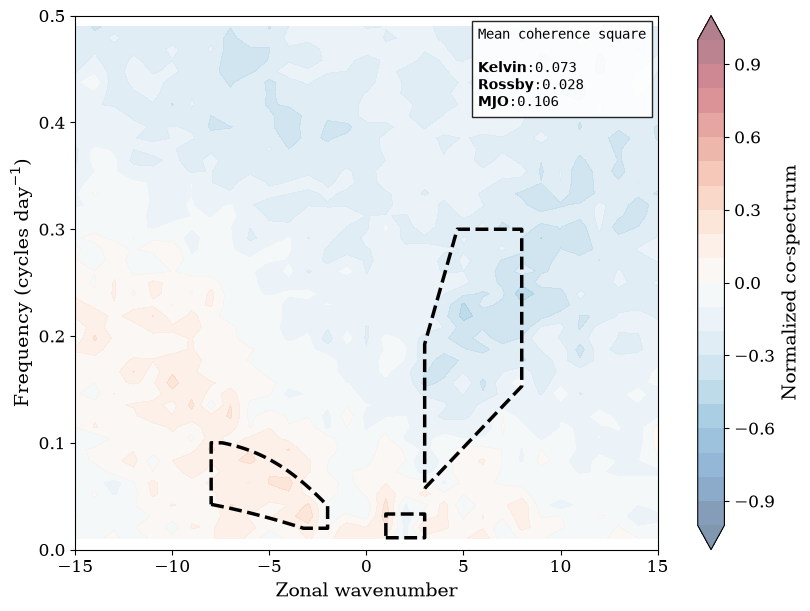

In [36]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

figure, axis = workflow.plot_cospectrum_with_coherence(
    shifted_wavenumbers,
    frequency_display,
    cospectrum_display,
    coherence_display,
    source_name=SOURCE_NAME,
    reference_name=REFERENCE_NAME,
    shading_levels=np.linspace(-1.0, 1.0, 21),
    coherence_levels=COHERENCE_LEVELS,
    equivalent_depths=EQUIVALENT_DEPTHS,
    cmap="RdBu_r",
    colorbar_label="Normalized co-spectrum",
    x_limits=(-15.0, 15.0),
    y_limits=(0.0, 0.5),
)

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
figure.savefig(
    OUTPUT_PATH / f"{SOURCE_NAME}.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()